In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import sympy as smp
from scipy.integrate import quad


In [2]:


# Plot style: white background with a clearly visible grid (cosmetic only)
sns.set_style("whitegrid")
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["grid.color"] = "black"
plt.rcParams["grid.linestyle"] = "-"
plt.rcParams["grid.linewidth"] = 1
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["axes.titlecolor"] = "black"



# Monte Carlo Integration

Four definite integrals estimated via Monte Carlo sampling, each compared against a
high-accuracy reference (`scipy.integrate.quad`) taken as the "true" value. For each case, the
percent error is computed at N = 10, 100, 1,000, and 10,000 random draws over the region of
interest, and N vs. error is plotted to show convergence.

a)

$$
\int_{1}^{1.5} x^2 \cdot \ln(x) \, dx
$$

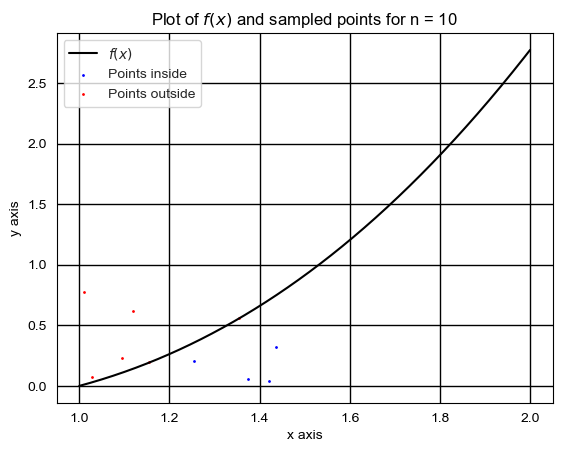

For n = 10:
Monte Carlo approximation: 0.17975242508969871
True value of the integral: 0.19225935773279604
Percent error: 6.51%



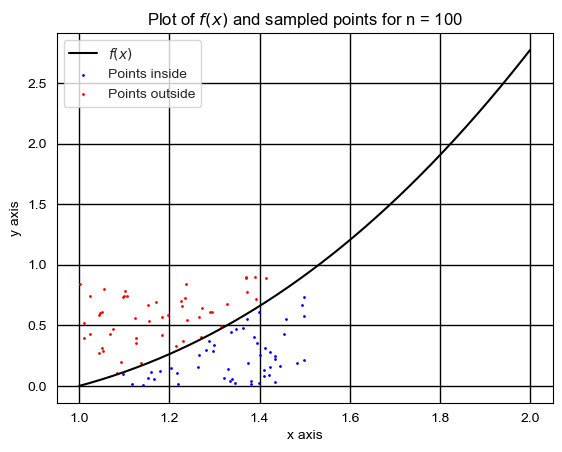

For n = 100:
Monte Carlo approximation: 0.22469053136212339
True value of the integral: 0.19225935773279604
Percent error: 16.87%



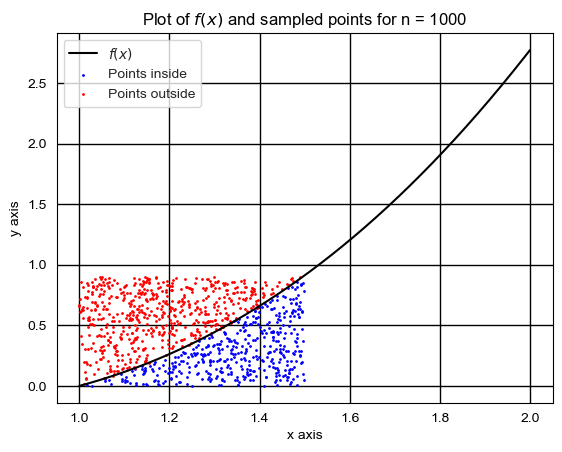

For n = 1000:
Monte Carlo approximation: 0.19008818953235637
True value of the integral: 0.19225935773279604
Percent error: 1.13%



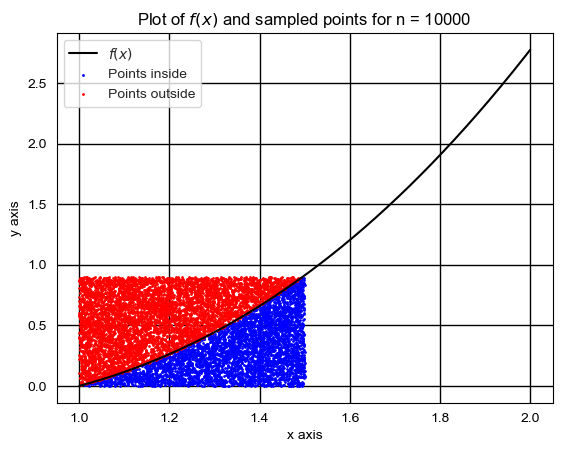

For n = 10000:
Monte Carlo approximation: 0.1899533752135391
True value of the integral: 0.19225935773279604
Percent error: 1.20%



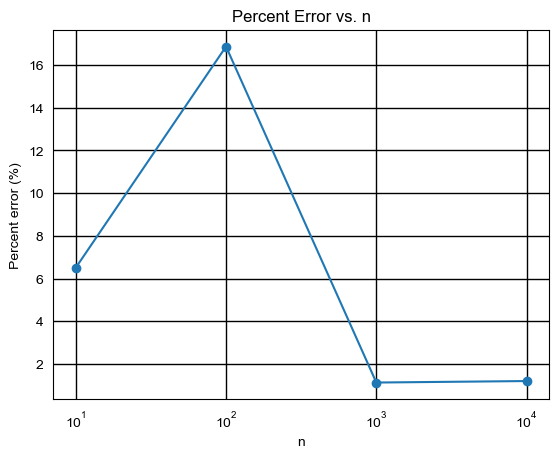

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import sympy as smp
from scipy.integrate import quad


# defining the function
def function(x):
    return x**2*np.log(x)

# integration limits
lower_limit = 1
upper_limit = 1.5

# generating values to plot the function
x_vals = np.linspace(1, 2, 1000)
y_vals = [function(x) for x in x_vals]

# to find ymax:
num_points = 100
dx = (upper_limit - lower_limit) / num_points
ymax = -float('inf')
for i in range(num_points): 
    aux = function(lower_limit + dx * i)
    if aux > ymax:
        ymax = aux

# area of the bounding rectangle
upper_area = (upper_limit - lower_limit) * ymax

# n values for which we compute the approximation and error, for comparison
n_values = [10, 100, 1000, 10000]

# lists to store errors
errors = []

# loop over different values of n
for n in n_values:
    points_inside = 0
    x_inside = []
    y_inside = []
    x_outside = []
    y_outside = []

    for j in range(n):
        x = np.random.uniform(lower_limit, upper_limit)
        y = np.random.uniform(0, ymax)
        if function(x) > y:
            points_inside += 1
            x_inside.append(x)
            y_inside.append(y)     
        else:
            x_outside.append(x)
            y_outside.append(y)

    # Approximation of the integral
    proportion = points_inside / n
    integral = upper_area * proportion

    # Computing the true integral
    true_integral, _ = quad(function, lower_limit, upper_limit)

    # Computing the error
    error = abs(100 * (true_integral - integral) / true_integral)
    errors.append(error)

    # Plotting the points
    plt.figure()
    plt.plot(x_vals, y_vals, label='$f(x)$', color='black')
    plt.scatter(x_inside, y_inside, color='blue', s=1, label='Points inside')
    plt.scatter(x_outside, y_outside, color='red', s=1, label='Points outside')
    plt.title(f'Plot of $f(x)$ and sampled points for n = {n}')
    plt.xlabel('x axis')
    plt.ylabel('y axis')
    plt.legend()
    plt.savefig("monte_carlo_rejection_sampling.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Showing results
    print(f"For n = {n}:")
    print(f"Monte Carlo approximation: {integral}")
    print(f"True value of the integral: {true_integral}")
    print(f"Percent error: {error:.2f}%")
    print()

# Plotting n vs error
plt.figure()
plt.plot(n_values, errors, marker='o')
plt.title('Percent Error vs. n')
plt.xlabel('n')
plt.ylabel('Percent error (%)')
plt.xscale('log')
plt.grid(True)
plt.savefig("monte_carlo_error_vs_n.png", dpi=150, bbox_inches="tight")
plt.show()


b)

$$
\int_{0}^{5}
2x \cdot \cos(2x) - (x - 2)^2 \, dx
$$

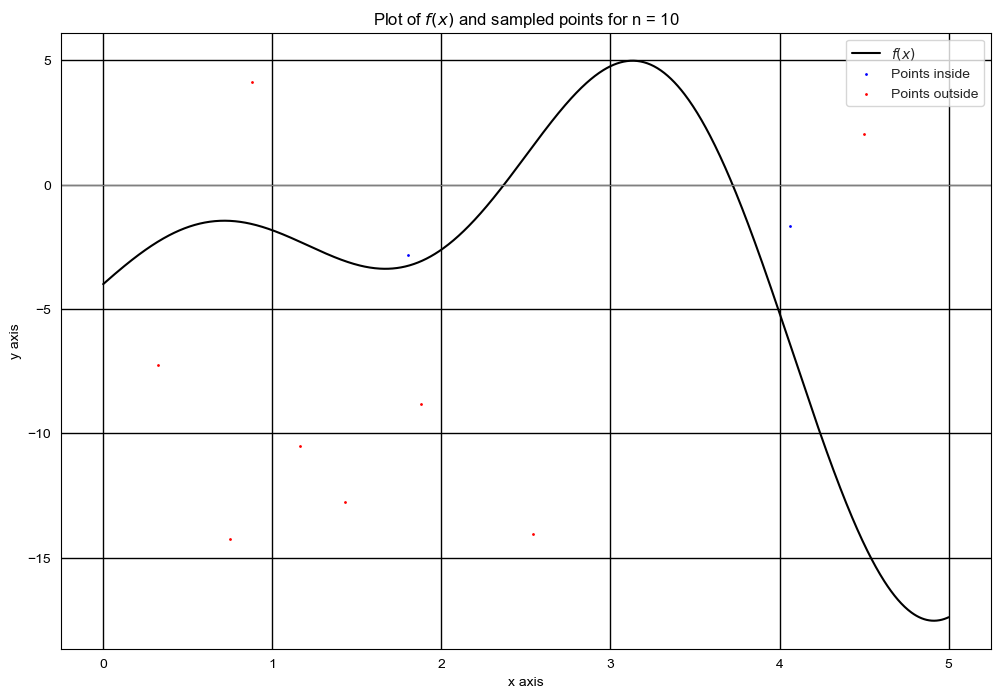

For n = 10:
Monte Carlo approximation: 22.512526931907775
True value of the integral: -15.306307985651745
Percent error: 247.08%



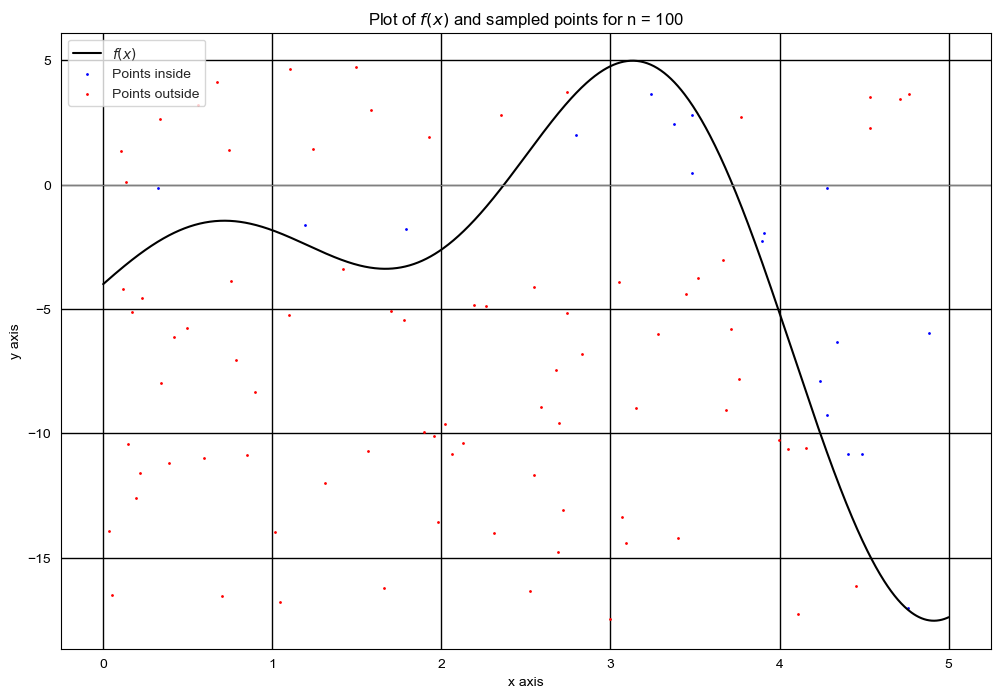

For n = 100:
Monte Carlo approximation: 20.261274238716997
True value of the integral: -15.306307985651745
Percent error: 232.37%



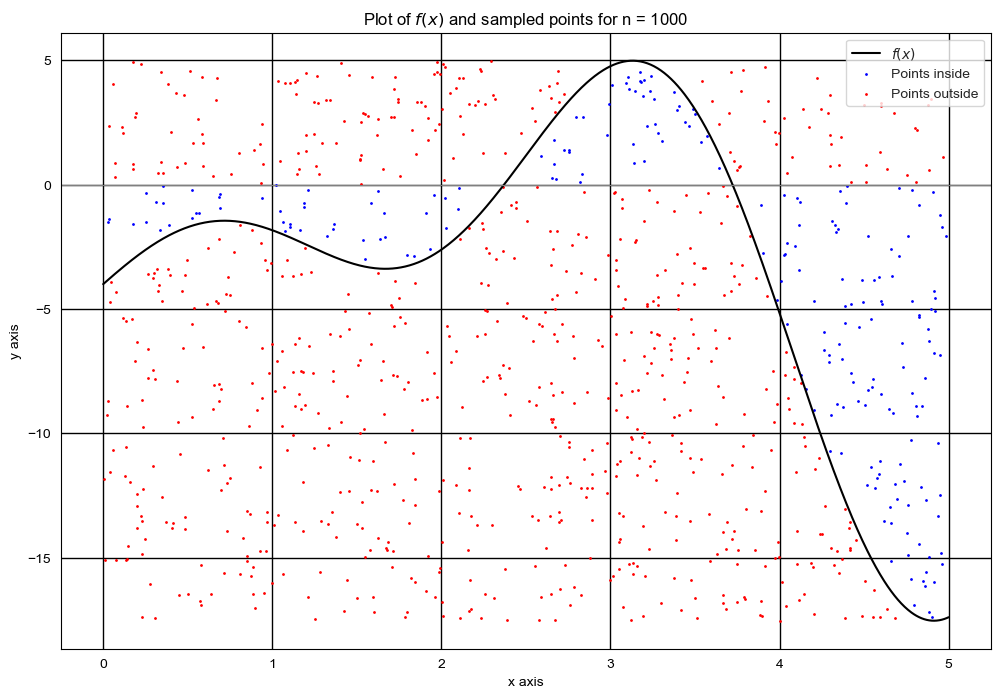

For n = 1000:
Monte Carlo approximation: 24.08840381714132
True value of the integral: -15.306307985651745
Percent error: 257.38%



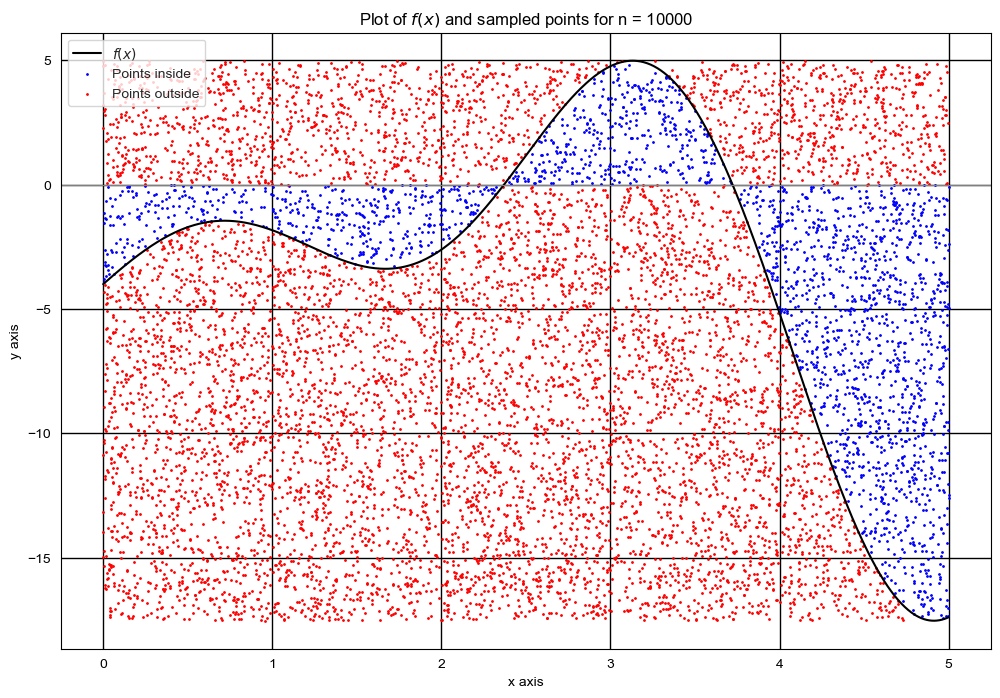

For n = 10000:
Monte Carlo approximation: 24.257247769130625
True value of the integral: -15.306307985651745
Percent error: 258.48%



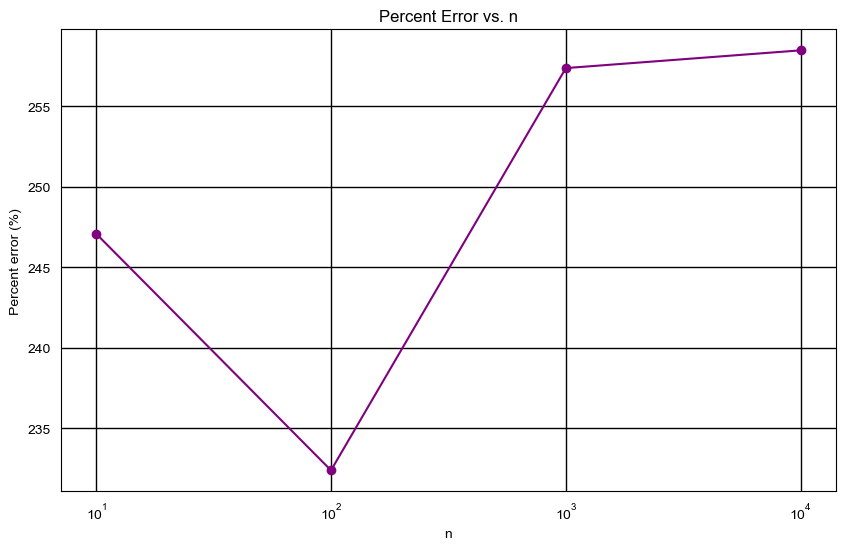

In [4]:

# Defining the function
def function(x):
    return 2 * x * np.cos(2 * x) - (x - 2)**2

# Integration limits
lower_limit = 0
upper_limit = 5

# Generating values to plot the function
x_vals = np.linspace(lower_limit, upper_limit, 1000)
y_vals = function(x_vals)

# Finding ymax and ymin
ymax = np.max(y_vals)
ymin = np.min(y_vals)

# Total area of the bounding rectangle
total_area = (upper_limit - lower_limit) * (ymax - ymin)

# n values for approximation and errors
n_vals = [10, 100, 1000, 10000]
errors = []

# Computing the true integral
true_integral, _ = quad(function, lower_limit, upper_limit)

# Loop over different values of n
for n in n_vals:
    points_inside = 0
    x_inside = []
    y_inside = []
    x_outside = []
    y_outside = []

    # Generate random points and check whether they fall inside the region
    for _ in range(n):
        x = np.random.uniform(lower_limit, upper_limit)
        y = np.random.uniform(ymin, ymax)
        fx = function(x)

        # Check whether the point is under the curve
        if (fx >= 0 and 0 <= y <= fx) or (fx < 0 and fx <= y <= 0):
            points_inside += 1
            x_inside.append(x)
            y_inside.append(y)
        else:
            x_outside.append(x)
            y_outside.append(y)

    # Approximation of the integral
    proportion = points_inside / n
    approx_integral = total_area * proportion

    # Computing the percent error
    error = abs(100 * (true_integral - approx_integral) / true_integral)
    errors.append(error)

    # Plotting points and function
    plt.figure(figsize=(12, 8))
    plt.plot(x_vals, y_vals, label='$f(x)$', color='black')
    plt.scatter(x_inside, y_inside, color='blue', s=1, label='Points inside')
    plt.scatter(x_outside, y_outside, color='red', s=1, label='Points outside')
    plt.axhline(0, color='grey', linewidth=0.8)
    plt.title(f'Plot of $f(x)$ and sampled points for n = {n}')
    plt.xlabel('x axis')
    plt.ylabel('y axis')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Showing results
    print(f"For n = {n}:")
    print(f"Monte Carlo approximation: {approx_integral}")
    print(f"True value of the integral: {true_integral}")
    print(f"Percent error: {error:.2f}%\n")

# Plotting n vs error
plt.figure(figsize=(10, 6))
plt.plot(n_vals, errors, marker='o', color='purple')
plt.title('Percent Error vs. n')
plt.xlabel('n')
plt.ylabel('Percent error (%)')
plt.xscale('log')
plt.grid(True)
plt.show()



c)

$$
\int_{0}^{48}
\sqrt{1 + \cos^3(x)} \, dx
$$


C:\Users\david\AppData\Local\Temp\ipykernel_30732\1090018377.py:55: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  true_integral, _ = quad(function, lower_limit, upper_limit)


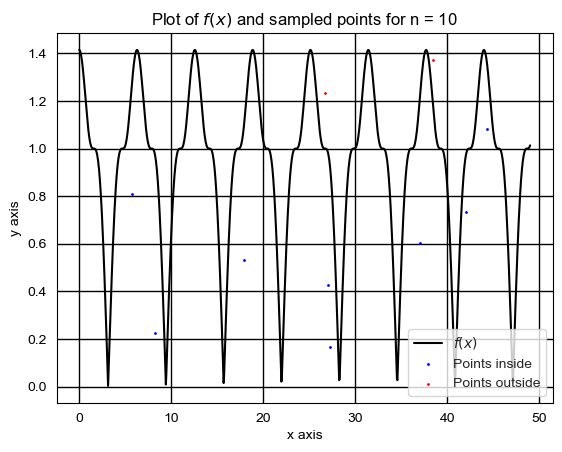

For n = 10:
Monte Carlo approximation: 54.305800795126856
True value of the integral: 44.66541222817148
Percent error: 21.58%



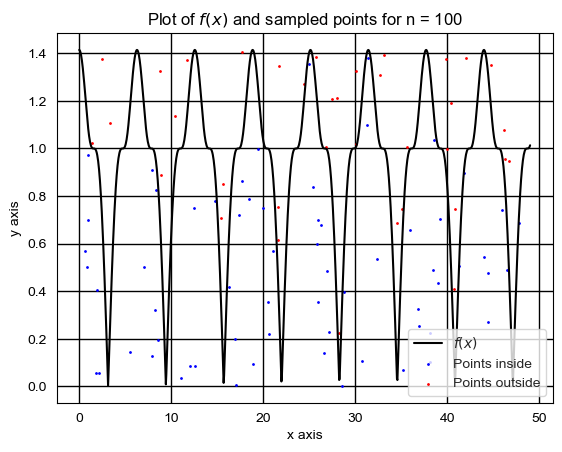

For n = 100:
Monte Carlo approximation: 43.44464063610149
True value of the integral: 44.66541222817148
Percent error: 2.73%



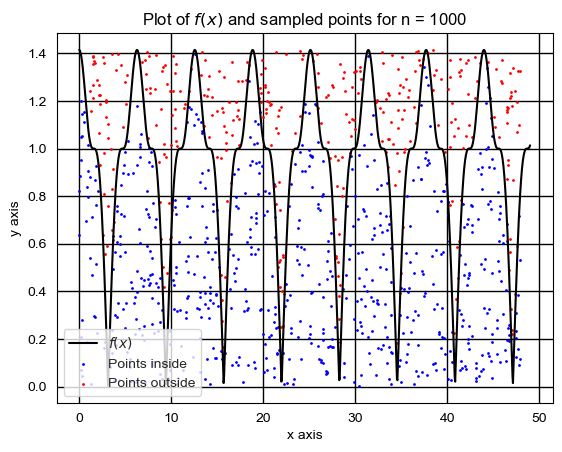

For n = 1000:
Monte Carlo approximation: 44.3271098990223
True value of the integral: 44.66541222817148
Percent error: 0.76%



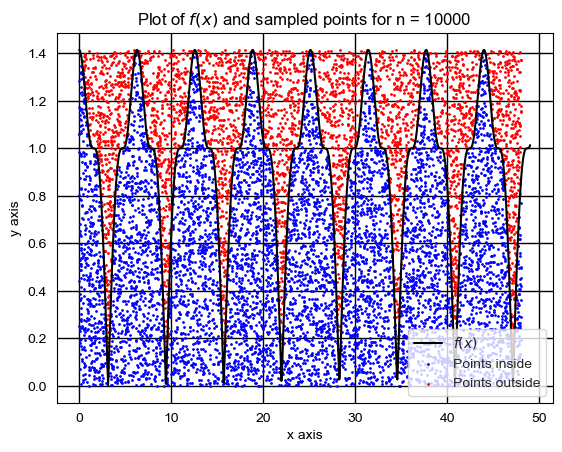

For n = 10000:
Monte Carlo approximation: 45.162061586247376
True value of the integral: 44.66541222817148
Percent error: 1.11%



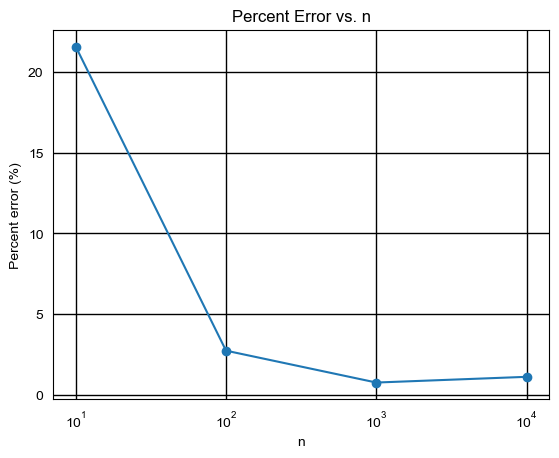

In [5]:
# defining the function
def function(x):
    return np.sqrt(1 + np.cos(x)**3)

# integration limits
lower_limit = 0
upper_limit = 48

# generating values to plot the function
x_vals = np.linspace(0, 49, 1000)
y_vals = [function(x) for x in x_vals]

# to find ymax:
num_points = 100
dx = (upper_limit - lower_limit) / num_points
ymax = -float('inf')
for i in range(num_points): 
    aux = function(lower_limit + dx * i)
    if aux > ymax:
        ymax = aux

# area of the bounding rectangle
upper_area = (upper_limit - lower_limit) * ymax

# n values for which we compute the approximation and error, for comparison
n_vals = [10, 100, 1000, 10000]

# lists to store errors
errors = []

# loop over different values of n
for n in n_vals:
    points_inside = 0
    x_inside = []
    y_inside = []
    x_outside = []
    y_outside = []

    for j in range(n):
        x = np.random.uniform(lower_limit, upper_limit)
        y = np.random.uniform(0, ymax)
        if function(x) > y:
            points_inside += 1
            x_inside.append(x)
            y_inside.append(y)     
        else:
            x_outside.append(x)
            y_outside.append(y)

    # numerical approximation of the integral
    proportion = points_inside / n
    integral = upper_area * proportion

    # computing the true integral
    true_integral, _ = quad(function, lower_limit, upper_limit)

    # computing the error
    error = abs(100 * (true_integral - integral) / true_integral)
    errors.append(error)

    # plotting the Monte Carlo points
    plt.figure()
    plt.plot(x_vals, y_vals, label='$f(x)$', color='black')
    plt.scatter(x_inside, y_inside, color='blue', s=1, label='Points inside')
    plt.scatter(x_outside, y_outside, color='red', s=1, label='Points outside')
    plt.title(f'Plot of $f(x)$ and sampled points for n = {n}')
    plt.xlabel('x axis')
    plt.ylabel('y axis')
    plt.legend()
    plt.show()

    # showing results
    print(f"For n = {n}:")
    print(f"Monte Carlo approximation: {integral}")
    print(f"True value of the integral: {true_integral}")
    print(f"Percent error: {error:.2f}%")
    print()

# plotting n vs error
plt.figure()
plt.plot(n_vals, errors, marker='o')
plt.title('Percent Error vs. n')
plt.xlabel('n')
plt.ylabel('Percent error (%)')
plt.xscale('log')
plt.grid(True)
plt.show()


d)
$$
\int_{e}^{2e}
\frac{1}{x \cdot \ln(x)} \, dx
$$

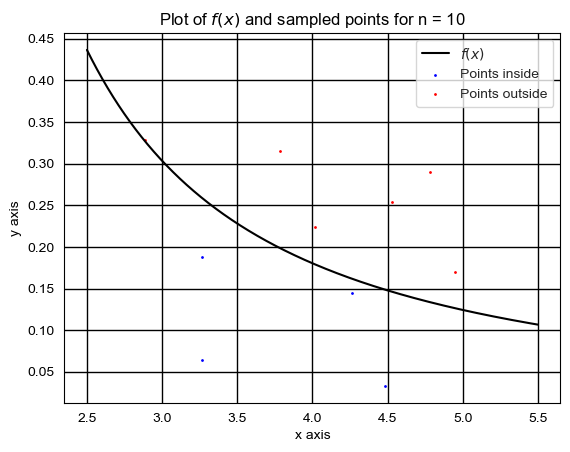

For n = 10:
Monte Carlo approximation: 0.4
True value of the integral: 0.5265890341390445
Percent error: 24.04%



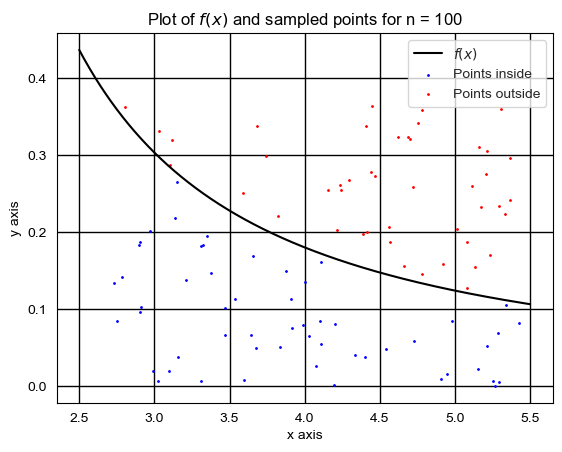

For n = 100:
Monte Carlo approximation: 0.55
True value of the integral: 0.5265890341390445
Percent error: 4.45%



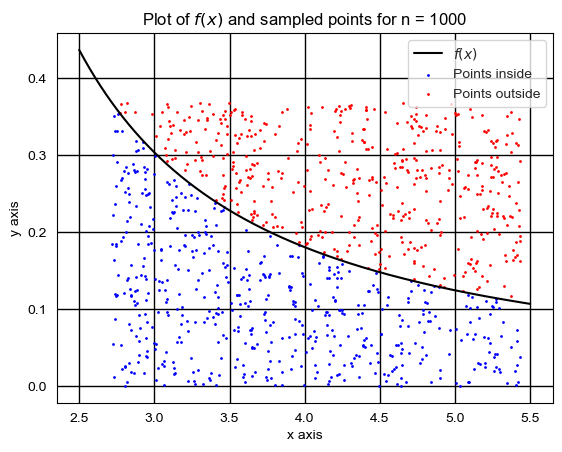

For n = 1000:
Monte Carlo approximation: 0.531
True value of the integral: 0.5265890341390445
Percent error: 0.84%



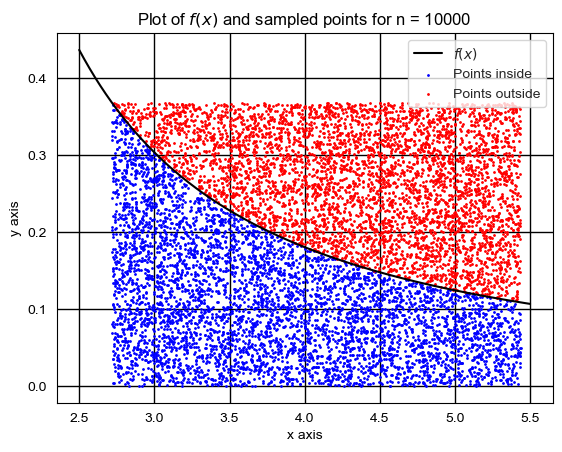

For n = 10000:
Monte Carlo approximation: 0.5234
True value of the integral: 0.5265890341390445
Percent error: 0.61%



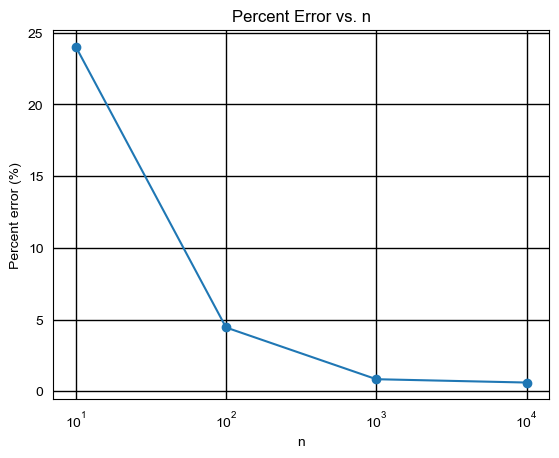

In [6]:
# defining the function
def function(x):
    return 1/(x*np.log(x))

# integration limits
lower_limit = np.e
upper_limit = 2*np.e

# generating values to plot the function
x_vals = np.linspace(2.5, 5.5, 1000)
y_vals = [function(x) for x in x_vals]

# to find ymax:
num_points = 100
dx = (upper_limit - lower_limit) / num_points
ymax = -float('inf')
for i in range(num_points): 
    aux = function(lower_limit + dx * i)
    if aux > ymax:
        ymax = aux

# area of the bounding rectangle
upper_area = (upper_limit - lower_limit) * ymax

# n values for which we compute the approximation and error, for comparison
n_vals = [10, 100, 1000, 10000]

# lists to store errors
errors = []

# loop over different values of n
for n in n_vals:
    points_inside = 0
    x_inside = []
    y_inside = []
    x_outside = []
    y_outside = []

    for j in range(n):
        x = np.random.uniform(lower_limit, upper_limit)
        y = np.random.uniform(0, ymax)
        if function(x) > y:
            points_inside += 1
            x_inside.append(x)
            y_inside.append(y)     
        else:
            x_outside.append(x)
            y_outside.append(y)

    # numerical approximation of the integral
    proportion = points_inside / n
    integral = upper_area * proportion

    # computing the true integral
    true_integral, _ = quad(function, lower_limit, upper_limit)

    # computing the error
    error = abs(100 * (true_integral - integral) / true_integral)
    errors.append(error)

    # plotting the Monte Carlo points
    plt.figure()
    plt.plot(x_vals, y_vals, label='$f(x)$', color='black')
    plt.scatter(x_inside, y_inside, color='blue', s=1, label='Points inside')
    plt.scatter(x_outside, y_outside, color='red', s=1, label='Points outside')
    plt.title(f'Plot of $f(x)$ and sampled points for n = {n}')
    plt.xlabel('x axis')
    plt.ylabel('y axis')
    plt.legend()
    plt.show()

    # showing results
    print(f"For n = {n}:")
    print(f"Monte Carlo approximation: {integral}")
    print(f"True value of the integral: {true_integral}")
    print(f"Percent error: {error:.2f}%")
    print()

# plotting n vs error
plt.figure()
plt.plot(n_vals, errors, marker='o')
plt.title('Percent Error vs. n')
plt.xlabel('n')
plt.ylabel('Percent error (%)')
plt.xscale('log')
plt.grid(True)
plt.show()


In most cases, increasing n visibly reduces the error when computing the integral numerically via
the Monte Carlo method.